In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
import subprocess, sys

db_uri = "sqlite:///mlflow_new.db"
mlflow.set_tracking_uri(db_uri)

# Автоматический upgrade схемы БД при смене версии MLflow (безопасно и для свежей БД)
result = subprocess.run(
    [sys.executable, "-m", "mlflow", "db", "upgrade", db_uri],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("База данных MLflow готова (миграция выполнена/не требовалась).")
else:
    print("Ошибка миграции БД:", result.stderr)

mlflow.set_experiment("Сравнение ML Классификации 3")

print(f"MLflow URI: {mlflow.get_tracking_uri()}")
print(f"Эксперимент: {mlflow.get_experiment_by_name('Сравнение ML Классификации 3').name}")

База данных MLflow готова (миграция выполнена/не требовалась).
MLflow URI: sqlite:///mlflow_new.db
Эксперимент: Сравнение ML Классификации 3


Set-ExecutionPolicy -Scope Process -ExecutionPolicy RemoteSigned
& c:\Users\Ruslan\Desktop\0964\.venv\Scripts\Activate.ps1

mlflow ui --backend-store-uri sqlite:///mlflow_new.db

In [35]:
df = pd.read_csv('synthetic_classification_dataset.csv')
print(f"Размер датасета: {df.shape}")
print("\nПервые 3 строки:")
print(df.head(3))

Размер датасета: (400, 7)

Первые 3 строки:
   income_level  age_group  credit_score_derived  debt_ratio_derived  \
0  51003.644037  34.075726            612.115477            0.135147   
1  48730.326452  54.688435            687.078294            0.391395   
2  55572.021476 -16.818661            429.631309            0.562403   

   zip_code  phone_area_code  target  
0     85057              783       2  
1     14228              453       1  
2     78725              601       2  


In [36]:
print("ОБЗОР ДАННЫХ")
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Количество классов: {df['target'].nunique()}")
print(f"Распределение классов: {df['target'].value_counts().to_dict()}")
print("\n7-point summary (описательная статистика):")
print(df.describe().round(2))

ОБЗОР ДАННЫХ
Пропуски: 0
Количество классов: 3
Распределение классов: {0: 135, 1: 134, 2: 131}

7-point summary (описательная статистика):
       income_level  age_group  credit_score_derived  debt_ratio_derived  \
count        400.00     400.00                400.00              400.00   
mean       47904.20      26.34                581.91                0.40   
std         7970.06      16.64                 58.89                0.31   
min        12229.33     -31.44                381.03               -0.44   
25%        44102.31      15.42                539.75                0.21   
50%        49647.41      29.03                589.73                0.42   
75%        52913.88      38.95                628.89                0.60   
max        74874.04      58.61                703.61                1.17   

       zip_code  phone_area_code  target  
count    400.00           400.00  400.00  
mean   56122.64           574.22    0.99  
std    26532.36           227.47    0.82  
min 

КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
income_level: 0.455
credit_score_derived: 0.212
age_group: 0.086
zip_code: 0.038
debt_ratio_derived: 0.020
phone_area_code: 0.015


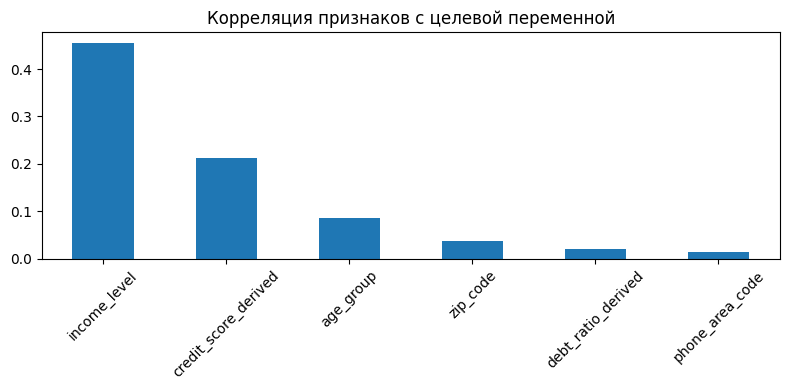


СБАЛАНС КЛАССОВ
Класс 0: 135 (33.8%)
Класс 1: 134 (33.5%)
Класс 2: 131 (32.8%)
Классы сбалансированы.

АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ
Различие средних: 14054201.2%
Различие стандартных отклонений: 8427068.2%
Рекомендуется масштабирование данных.


In [37]:
# Корреляция с целевой переменной — быстрый расчёт
print("КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
correlations = df.drop('target', axis=1).corrwith(df['target']).sort_values(key=abs, ascending=False)
for feature, corr in correlations.items():
    print(f"{feature}: {corr:.3f}")

# Визуализация — эффективная
plt.figure(figsize=(8, 4))
correlations.plot(kind='bar')
plt.title('Корреляция признаков с целевой переменной')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Сбалансированы ли классы?
print("\nСБАЛАНС КЛАССОВ")
class_counts = df['target'].value_counts()
total = len(df)
for cls, count in class_counts.items():
    pct = count / total * 100
    print(f"Класс {cls}: {count} ({pct:.1f}%)")
if class_counts.std() / class_counts.mean() < 0.1:
    print("Классы сбалансированы.")
else:
    print("Классы не сбалансированы.")

# Стоит ли масштабировать данные?
print("\nАНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ")
feature_stats = df.drop('target', axis=1).describe().transpose()
means = feature_stats['mean']
stds = feature_stats['std']
mean_diff = (means.max() - means.min()) / means.min() * 100
std_diff = (stds.max() - stds.min()) / stds.min() * 100
print(f"Различие средних: {mean_diff:.1f}%")
print(f"Различие стандартных отклонений: {std_diff:.1f}%")
if mean_diff > 50 or std_diff > 50:
    print("Рекомендуется масштабирование данных.")
else:
    print("Масштабирование не требуется.")

In [38]:
# Подготовка данных — оптимальная
X = df.drop('target', axis=1)
y = df['target']

# Разделение — стратифицированное для баланса
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирование — только для нужных моделей
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape}, Тестовая: {X_test.shape}")
print(f"Классы (обучение): {y_train.value_counts().to_dict()}")
print(f"Классы (тест): {y_test.value_counts().to_dict()}")

# Проверка гипотезы о нормальности распределения
from scipy.stats import shapiro
print("\nПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ")
feature_to_test = 'age_group'  # Выберем один признак
stat, p_value = shapiro(df[feature_to_test])
print(f"Тест Шапиро-Уилка для {feature_to_test}:")
print(f"Статистика: {stat:.3f}, p-значение: {p_value:.3f}")
if p_value > 0.05:
    print("Распределение нормально (не отвергаем H0).")
else:
    print("Распределение не нормально (отвергаем H0).")

Обучающая выборка: (320, 6), Тестовая: (80, 6)
Классы (обучение): {0: 108, 1: 107, 2: 105}
Классы (тест): {1: 27, 0: 27, 2: 26}

ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ
Тест Шапиро-Уилка для age_group:
Статистика: 0.976, p-значение: 0.000
Распределение не нормально (отвергаем H0).


In [39]:
# Анализ масштабов признаков — быстрый
print("АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ")
feature_stats = df.drop('target', axis=1).describe().transpose()

max_mean = feature_stats['mean'].max()
min_mean = feature_stats['mean'].min()
scale_diff = (max_mean - min_mean) / min_mean * 100

print(f"Макс. среднее: {max_mean:.2f}")
print(f"Мин. среднее: {min_mean:.2f}")
print(f"Различие масштабов: {scale_diff:.1f}%")

if scale_diff > 50:
    print("МАСШТАБИРОВАНИЕ ОБЯЗАТЕЛЬНО")
else:
    print("Масштабирование не требуется")


def train_and_evaluate_mlflow(model, param_grid, X_train, X_test, y_train, y_test, model_name, use_scaled=False):
    """Обучает модель и логирует в MLflow """
    
    # Выбор данных
    train_data = X_train_scaled if use_scaled else X_train
    test_data = X_test_scaled if use_scaled else X_test
    
    with mlflow.start_run(run_name=model_name) as run:
        # Подбор гиперпараметров с CV
        grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        grid_search.fit(train_data, y_train)
        best_model = grid_search.best_estimator_
        
        # Логирование параметров
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("scaling", use_scaled)
        mlflow.log_param("best_hyperparams", grid_search.best_params_)
        mlflow.log_param("cv_f1", grid_search.best_score_)
        mlflow.log_param("train_size", len(X_train))
        mlflow.log_param("test_size", len(X_test))
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("n_classes", len(np.unique(y_train)))
        
        # Предсказания
        y_train_pred = best_model.predict(train_data)
        y_test_pred = best_model.predict(test_data)
        
        # Метрики — быстрый расчёт
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred, average='weighted')
        overfitting = train_acc - test_acc
        
        # Логирование метрик
        mlflow.log_metric("train_accuracy", train_acc)
        mlflow.log_metric("test_accuracy", test_acc)
        mlflow.log_metric("test_f1", test_f1)
        mlflow.log_metric("overfitting", overfitting)
        
        # Логирование матрицы ошибок — оптимизированное
        cm = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix — {model_name}')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
        plt.close()
        mlflow.log_artifact('confusion_matrix.png')
        
        # Логирование модели
        signature = infer_signature(train_data, best_model.predict(train_data))
        mlflow.sklearn.log_model(best_model, "model", signature=signature)
        
        # Логирование информации о данных
        dataset_info = {
            'train_shape': train_data.shape,
            'test_shape': test_data.shape,
            'feature_names': list(X_train.columns)
        }
        mlflow.log_dict(dataset_info, "dataset_info.json")
        
        print(f"  Лучшие параметры: {grid_search.best_params_}")
        print(f"  CV F1: {grid_search.best_score_:.3f}")
        print(f"  Обучение: {train_acc:.3f}, Тест: {test_acc:.3f}, F1: {test_f1:.3f}")
        
        metrics = {
            'model': model_name,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'test_f1': test_f1,
            'overfitting': overfitting,
            'cv_f1': grid_search.best_score_,
            'run_id': run.info.run_id
        }
        
        return metrics, best_model, run.info.run_id

АНАЛИЗ МАСШТАБОВ ПРИЗНАКОВ
Макс. среднее: 56122.64
Мин. среднее: 0.40
Различие масштабов: 14054201.2%
МАСШТАБИРОВАНИЕ ОБЯЗАТЕЛЬНО


In [40]:

results = []
models = {}
run_ids = {}


print("\nЛогистическая регрессия.")
lr = LogisticRegression(random_state=42, max_iter=2000)
param_grid_lr = {'C': [0.01, 0.1, 1], 'solver': ['lbfgs']}
metrics, model, run_id = train_and_evaluate_mlflow(
    lr, param_grid_lr, X_train, X_test, y_train, y_test, "Логистическая Регрессия", use_scaled=True
)
results.append(metrics)
models['lr'] = model
run_ids['lr'] = run_id


print("\nKNN.")
knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': [5, 7, 10, 15], 'weights': ['uniform', 'distance']}
metrics, model, run_id = train_and_evaluate_mlflow(
    knn, param_grid_knn, X_train, X_test, y_train, y_test, "KNN", use_scaled=True
)
results.append(metrics)
models['knn'] = model
run_ids['knn'] = run_id


print("\nSVM.")
svm = SVC(random_state=42, probability=True, gamma='scale')
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
metrics, model, run_id = train_and_evaluate_mlflow(
    svm, param_grid_svm, X_train, X_test, y_train, y_test, "SVM", use_scaled=True
)
results.append(metrics)
models['svm'] = model
run_ids['svm'] = run_id


print("\nДерево решений")
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {'max_depth': [2, 3, 5], 'min_samples_split': [5, 10, 20], 'min_samples_leaf': [2, 5, 10]}
metrics, model, run_id = train_and_evaluate_mlflow(
    dt, param_grid_dt, X_train, X_test, y_train, y_test, "Дерево Решений", use_scaled=False
)
results.append(metrics)
models['dt'] = model
run_ids['dt'] = run_id


print("\nНаивный Байес.")
nb = GaussianNB()
param_grid_nb = {}  # Нет гиперпараметров для подбора
metrics, model, run_id = train_and_evaluate_mlflow(
    nb, param_grid_nb, X_train, X_test, y_train, y_test, "Наивный Байес", use_scaled=False
)
results.append(metrics)
models['nb'] = model
run_ids['nb'] = run_id


print("\nСлучайный лес.")
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [3, 5, 7], 'min_samples_split': [5, 10], 'min_samples_leaf': [2, 5]}
metrics, model, run_id = train_and_evaluate_mlflow(
    rf, param_grid_rf, X_train, X_test, y_train, y_test, "Случайный Лес", use_scaled=False
)
results.append(metrics)
models['rf'] = model
run_ids['rf'] = run_id


print("\nБэггинг.")
from sklearn.tree import DecisionTreeClassifier as DTC
bg = BaggingClassifier(estimator=DTC(max_depth=3, min_samples_leaf=5, random_state=42), random_state=42)
param_grid_bg = {'n_estimators': [10, 50], 'max_samples': [0.8, 1.0]}
metrics, model, run_id = train_and_evaluate_mlflow(
    bg, param_grid_bg, X_train, X_test, y_train, y_test, "Бэггинг", use_scaled=False
)
results.append(metrics)
models['bg'] = model
run_ids['bg'] = run_id


print("\nГрадиентный бустинг.")
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.05], 'max_depth': [2, 3], 'subsample': [0.8, 1.0], 'min_samples_split': [5, 10]}
metrics, model, run_id = train_and_evaluate_mlflow(
    gb, param_grid_gb, X_train, X_test, y_train, y_test, "Градиентный Бустинг", use_scaled=False
)
results.append(metrics)
models['gb'] = model
run_ids['gb'] = run_id


print("\nСтекинг.")
estimators = [
    ('lr', LogisticRegression(random_state=42, max_iter=2000, C=1.0)),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=50, max_depth=5, min_samples_leaf=5)),
    ('gb', GradientBoostingClassifier(random_state=42, n_estimators=50, max_depth=3, learning_rate=0.05))
]
st = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=42, max_iter=2000, C=0.1))
param_grid_st = {}  # Простой стекинг без подбора
metrics, model, run_id = train_and_evaluate_mlflow(
    st, param_grid_st, X_train, X_test, y_train, y_test, "Стекинг", use_scaled=False
)
results.append(metrics)
models['st'] = model
run_ids['st'] = run_id

print("\nВсе модели обучены и залогированы в MLflow!")


Логистическая регрессия.


2026/05/09 14:30:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 14:30:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Лучшие параметры: {'C': 0.1, 'solver': 'lbfgs'}
  CV F1: 0.710
  Обучение: 0.722, Тест: 0.637, F1: 0.634

KNN.


2026/05/09 14:30:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 14:30:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Лучшие параметры: {'n_neighbors': 10, 'weights': 'distance'}
  CV F1: 0.717
  Обучение: 1.000, Тест: 0.675, F1: 0.673

SVM.


...

  Лучшие параметры: {'max_samples': 1.0, 'n_estimators': 10}
  CV F1: 0.828
  Обучение: 0.847, Тест: 0.825, F1: 0.824

Градиентный бустинг.


c:\Users\Ruslan\Desktop\0964\.venv1\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/05/09 14:31:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 14:31:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising 

  Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 1.0}
  CV F1: 0.871
  Обучение: 0.975, Тест: 0.812, F1: 0.812

Стекинг.


c:\Users\Ruslan\Desktop\0964\.venv1\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Ruslan\Desktop\0964\.venv1\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

  Лучшие параметры: {}
  CV F1: 0.847
  Обучение: 0.909, Тест: 0.850, F1: 0.850

Все модели обучены и залогированы в MLflow!


СРАВНЕНИЕ МОДЕЛЕЙ
                  model  train_acc  test_acc  test_f1  overfitting  cv_f1
                Стекинг      0.909     0.850    0.850        0.059  0.847
         Дерево Решений      0.853     0.838    0.838        0.016  0.822
          Случайный Лес      0.950     0.825    0.826        0.125  0.831
                Бэггинг      0.847     0.825    0.824        0.022  0.828
                    SVM      0.800     0.812    0.815       -0.012  0.783
    Градиентный Бустинг      0.975     0.812    0.812        0.162  0.871
          Наивный Байес      0.806     0.750    0.749        0.056  0.797
                    KNN      1.000     0.675    0.673        0.325  0.717
Логистическая Регрессия      0.722     0.638    0.634        0.084  0.710


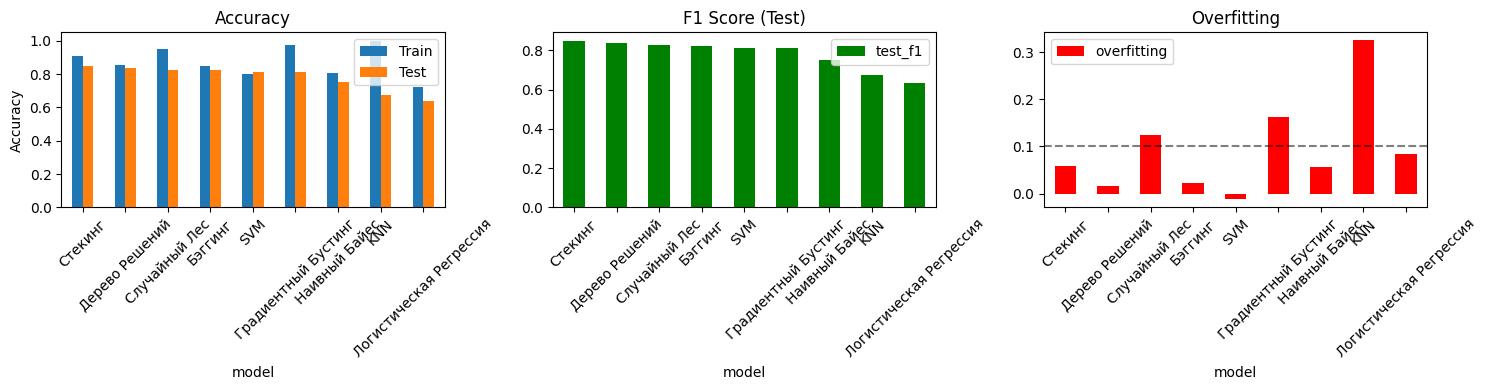

In [41]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_f1', ascending=False)

print("СРАВНЕНИЕ МОДЕЛЕЙ")
display_df = results_df.drop('run_id', axis=1).round(3)
print(display_df.to_string(index=False))


fig, axes = plt.subplots(1, 3, figsize=(15, 4))


results_df.plot(kind='bar', x='model', y=['train_acc', 'test_acc'], ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].legend(['Train', 'Test'])
axes[0].tick_params(axis='x', rotation=45)


results_df.plot(kind='bar', x='model', y='test_f1', ax=axes[1], color='green')
axes[1].set_title('F1 Score (Test)')
axes[1].tick_params(axis='x', rotation=45)


results_df.plot(kind='bar', x='model', y='overfitting', ax=axes[2], color='red')
axes[2].set_title('Overfitting')
axes[2].axhline(y=0.1, color='black', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


with mlflow.start_run(run_name="Model_Comparison") as run:
    mlflow.log_dict(display_df.to_dict(), "model_comparison.json")
    
    
    plt.figure(figsize=(12, 6))
    results_df_melted = results_df.melt(id_vars=['model'], 
                                        value_vars=['train_acc', 'test_acc', 'test_f1', 'cv_f1'],
                                        var_name='metric', value_name='value')
    sns.barplot(data=results_df_melted, x='model', y='value', hue='metric')
    plt.title('Model Performance Comparison')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
    plt.close()
    mlflow.log_artifact('model_comparison.png')

In [42]:

print("АНАЛИЗ ПЕРЕОБУЧЕНИЯ")
overfit_threshold = 0.1

overfitting = results_df[results_df['overfitting'] > overfit_threshold]
stable = results_df[results_df['overfitting'] <= overfit_threshold]

print(f"Модели с переобучением (> {overfit_threshold}):")
if len(overfitting) > 0:
    for _, row in overfitting.iterrows():
        print(f"  - {row['model']}: {row['overfitting']:.3f}")
else:
    print("  Нет")

print(f"\nСтабильные модели (<= {overfit_threshold}):")
for _, row in stable.iterrows():
    print(f"  - {row['model']}: {row['overfitting']:.3f}")

АНАЛИЗ ПЕРЕОБУЧЕНИЯ
Модели с переобучением (> 0.1):
  - Случайный Лес: 0.125
  - Градиентный Бустинг: 0.162
  - KNN: 0.325

Стабильные модели (<= 0.1):
  - Стекинг: 0.059
  - Дерево Решений: 0.016
  - Бэггинг: 0.022
  - SVM: -0.012
  - Наивный Байес: 0.056
  - Логистическая Регрессия: 0.084


In [43]:

print("ТОП-3 МОДЕЛИ")
top_3 = results_df.head(3)
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    print(f"{i}. {row['model']} — F1: {row['test_f1']:.3f}, Точность: {row['test_acc']:.3f}")


best_model_name = results_df.iloc[0]['model']
best_run_id = results_df.iloc[0]['run_id']
print(f"\nЛучшая модель: {best_model_name}")
print(f"MLflow Run ID: {best_run_id}")


print("\nПодробный отчёт лучшей модели")
model_mapping = {
    'Логистическая Регрессия': (models['lr'], True),
    'KNN': (models['knn'], True),
    'SVM': (models['svm'], True),
    'Наивный Байес': (models['nb'], False),
    'Дерево Решений': (models['dt'], False),
    'Случайный Лес': (models['rf'], False),
    'Бэггинг': (models['bg'], False),
    'Градиентный Бустинг': (models['gb'], False),
    'Стекинг': (models['st'], False)
}

best_model, use_scaled = model_mapping.get(best_model_name)
if best_model:
    X_test_final = X_test_scaled if use_scaled else X_test
    y_pred = best_model.predict(X_test_final)
    print(classification_report(y_test, y_pred))

ТОП-3 МОДЕЛИ
1. Стекинг — F1: 0.850, Точность: 0.850
2. Дерево Решений — F1: 0.838, Точность: 0.838
3. Случайный Лес — F1: 0.826, Точность: 0.825

Лучшая модель: Стекинг
MLflow Run ID: 11fd3ae5608449c1842187d260c32ef5

Подробный отчёт лучшей модели
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        27
           1       0.81      0.81      0.81        27
           2       0.81      0.81      0.81        26

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.85      0.85      0.85        80



In [44]:
print("СВОДКА ПО ЭКСПЕРИМЕНТУ MLflow")
experiment = mlflow.get_experiment_by_name("Сравнение ML Классификации 3")
print(f"Эксперимент: {experiment.name}")
print(f"ID эксперимента: {experiment.experiment_id}")
print(f"URI отслеживания: {mlflow.get_tracking_uri()}")


runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

print(f"\nВсего запусков: {len(runs)}")
print("\nДетали запусков:")
for _, run in runs.iterrows():
    print(f"  - {run['tags.mlflow.runName']}: F1={run['metrics.test_f1']:.3f}, Accuracy={run['metrics.test_accuracy']:.3f}")

СВОДКА ПО ЭКСПЕРИМЕНТУ MLflow
Эксперимент: Сравнение ML Классификации 3
ID эксперимента: 2
URI отслеживания: sqlite:///mlflow_new.db

Всего запусков: 39

Детали запусков:
  - Model_Comparison: F1=nan, Accuracy=nan
  - Стекинг: F1=0.850, Accuracy=0.850
  - Градиентный Бустинг: F1=0.812, Accuracy=0.812
  - Бэггинг: F1=0.824, Accuracy=0.825
  - Случайный Лес: F1=0.826, Accuracy=0.825
  - Наивный Байес: F1=0.749, Accuracy=0.750
  - Дерево Решений: F1=0.838, Accuracy=0.838
  - SVM: F1=0.815, Accuracy=0.812
  - KNN: F1=0.673, Accuracy=0.675
  - Логистическая Регрессия: F1=0.634, Accuracy=0.637
  - Model_Comparison: F1=nan, Accuracy=nan
  - Стекинг: F1=0.517, Accuracy=0.512
  - Градиентный Бустинг: F1=0.528, Accuracy=0.525
  - Бэггинг: F1=0.488, Accuracy=0.487
  - Случайный Лес: F1=0.480, Accuracy=0.475
  - Наивный Байес: F1=0.360, Accuracy=0.388
  - Дерево Решений: F1=0.435, Accuracy=0.438
  - SVM: F1=0.481, Accuracy=0.475
  - KNN: F1=0.450, Accuracy=0.450
  - Логистическая Регрессия: F1=0.4

In [45]:

print("ИТОГОВЫЕ ВЫВОДЫ")
print(f"1. Лучшая модель: {best_model_name}")
print(f"2. Качество (F1): {results_df.iloc[0]['test_f1']:.3f}")
print(f"3. Точность: {results_df.iloc[0]['test_acc']:.3f}")
print(f"4. Моделей с переобучением: {len(overfitting)} из {len(results_df)}")




ИТОГОВЫЕ ВЫВОДЫ
1. Лучшая модель: Стекинг
2. Качество (F1): 0.850
3. Точность: 0.850
4. Моделей с переобучением: 3 из 9
